In [61]:
import pennylane as qml
from pennylane import numpy as np

In [62]:
np.random.seed(499122177)

In [ ]:
def init_graph():
    n, e = [int(x) for x in input("Enter the number of vertices and edges: ").split()]
    edges = []
    for _ in range(e):
        u, v = [int(x) for x in input().split()]
        edges.append([u, v])

    return [n, edges]

In [64]:
def U_B(qubits, beta):
    for qubit in range(qubits):
        qml.RX(2 * beta, wires = qubit)

In [65]:
def U_C(edges, gamma):
    for edge in edges:
        qml.CNOT(wires = edge)
        qml.RZ(gamma, wires = edge[1])
        qml.CNOT(wires = edge)

In [66]:
def bitstring_to_int(bit_string):
    return int(2 ** np.arange(len(bit_string)) @ bit_string[::-1])

In [128]:
qubits, edges = init_graph()

Provide inputs, or press Enter to use the default 10-node graph.
Using default graph: 10 vertices, 20 edges


In [93]:
dev = qml.device('default.qubit', wires = qubits)
@qml.set_shots(1024)
@qml.qnode(dev)
def ckt(qubits, edges, gammas, betas, return_samples = False):
    assert(len(gammas) == len(betas))

    for i in range(qubits):
        qml.Hadamard(wires = i)
    for gamma, beta in zip(gammas, betas):
        U_C(edges, gamma)
        U_B(qubits, beta)

    if return_samples:
        qml.sample()

    H = qml.sum(*(qml.Z(w1) @ qml.Z(w2) for w1, w2 in edges))
    return qml.expval(H)


In [94]:
def objective(params, qubits, edges):
    gammas = params[0]
    betas = params[1]
    return -0.5 * (len(edges) - ckt(qubits, edges, gammas, betas))

In [97]:
def qaoa_maxcut(qubits, edges, n_layers = 1, epochs=30):
    objectives = []
    init_params = 0.01 * np.random.rand(2, n_layers, requires_grad = True)
    opt = qml.AdagradOptimizer(stepsize = 0.05)

    params = init_params.copy()
    steps = epochs

    for i in range(steps):
        params = opt.step(objective, params, qubits=qubits, edges=edges)
        objectives.append(objective(params, qubits=qubits, edges=edges))
        if (i + 1) % 5 == 0:
            print(f"Objective after step {i + 1:3d}: {objective(params, qubits=qubits, edges=edges): .7f}")
    return params, objectives

In [98]:
params, objectives = qaoa_maxcut(qubits, edges, n_layers=3, epochs=150)


Objective after step   5: -11.6386719
Objective after step  10: -12.9023438
Objective after step  15: -13.1591797
Objective after step  20: -13.1933594
Objective after step  25: -13.4462891
Objective after step  30: -13.5751953
Objective after step  35: -13.7080078
Objective after step  40: -13.7636719
Objective after step  45: -13.8642578
Objective after step  50: -13.8222656
Objective after step  55: -13.9726562
Objective after step  60: -13.9003906
Objective after step  65: -13.8173828
Objective after step  70: -14.0468750
Objective after step  75: -13.9208984
Objective after step  80: -14.0380859
Objective after step  85: -14.0615234
Objective after step  90: -14.1123047
Objective after step  95: -13.9765625
Objective after step 100: -14.0429688
Objective after step 105: -14.1298828
Objective after step 110: -14.1718750
Objective after step 115: -14.1718750
Objective after step 120: -14.1201172
Objective after step 125: -14.1669922
Objective after step 130: -14.3271484
Objective af

In [121]:
params

tensor([[ 0.32457035,  0.60429356,  0.74016562],
        [-0.51285089, -0.37183288, -0.20610625]], requires_grad=True)

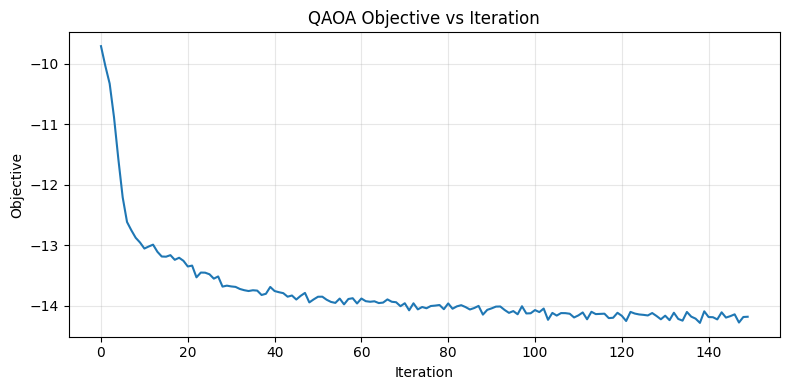

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(objectives)
plt.title("QAOA Objective vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Most probable bitstring: 0101101110


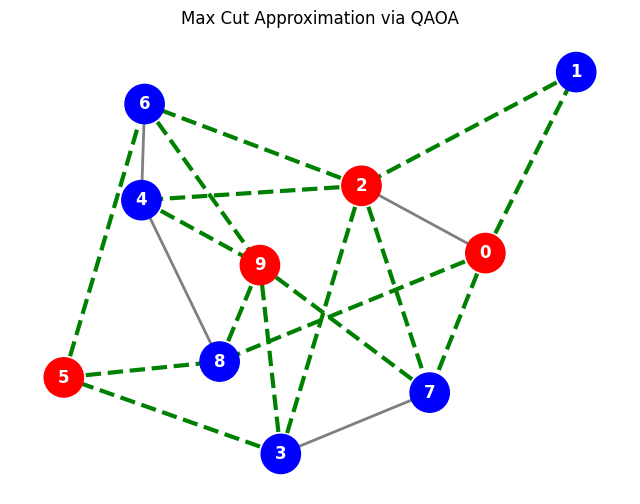

In [132]:
import networkx as nx
import matplotlib.pyplot as plt

# Get the most probable state
@qml.qnode(dev)
def get_probs(qubits, edges, gammas, betas):
    for i in range(qubits):
        qml.Hadamard(wires=i)
    for gamma, beta in zip(gammas, betas):
        U_C(edges, gamma)
        U_B(qubits, beta)
    return qml.probs(wires=range(qubits))

probs = get_probs(qubits, edges, params[0], params[1])
most_probable_state = np.argmax(probs)
bitstring = format(most_probable_state, f'0{qubits}b')
print(f"Most probable bitstring: {bitstring}")

# Create the graph
G = nx.Graph()
G.add_nodes_from(range(qubits))
G.add_edges_from(edges)

# Colors based on bitstring (partition)
colors = ['red' if bit == '0' else 'blue' for bit in bitstring]

# Draw the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=800)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold')

# Draw edges, highlight cut edges
cut_edges = []
uncut_edges = []
for u, v in G.edges():
    if bitstring[u] != bitstring[v]:
        cut_edges.append((u, v))
    else:
        uncut_edges.append((u, v))

nx.draw_networkx_edges(G, pos, edgelist=uncut_edges, width=2, alpha=0.5)
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, width=3, edge_color='green', style='dashed') # Cut edges in green dashed

plt.title("Max Cut Approximation via QAOA")
plt.axis('off')
plt.show()

In [101]:
len(cut_edges)

16

In [102]:
len(uncut_edges)

4